# EDA - Processed Book Dataset

This notebook analyzes the processed dataset located at `data/processed/book_dataset_clean_locked_rows_run2.csv`.

Main goals:
- Evaluate dataset overview: sample size, structure, and data types.
- Audit data quality: duplicates and missing values.
- Analyze distributions of key numeric and categorical variables.
- Explore relationships among price, discount, rating, reviews, and sales.
- Summarize actionable insights for dashboard and Lab01 reporting.

In [5]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", context="notebook")


def resolve_project_root(start: Path, markers=("data", "src", "notebooks")) -> Path:
    for candidate in (start, *start.parents):
        if all((candidate / marker).exists() for marker in markers):
            return candidate
    raise RuntimeError(
        "Could not locate PlotTwist project root from the current working directory. "
        "Set MANUAL_PROJECT_ROOT below if your notebook kernel starts outside the project."
    )


MANUAL_PROJECT_ROOT = None
PROJECT_ROOT = Path(MANUAL_PROJECT_ROOT) if MANUAL_PROJECT_ROOT else resolve_project_root(Path.cwd())

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "book_dataset_clean_locked_rows_run2.csv"
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Processed file not found: {DATA_PATH}")

df = pd.read_csv(DATA_PATH, encoding="utf-8-sig", low_memory=False)
if "publication_date" in df.columns:
    df["publication_date"] = pd.to_datetime(df["publication_date"], errors="coerce")

print(f"Current working directory: {Path.cwd()}")
print(f"Resolved project root: {PROJECT_ROOT}")
print(f"Loaded file: {DATA_PATH}")
print(f"Rows: {len(df):,} | Columns: {df.shape[1]}")
display(df.head(5))

Current working directory: c:\Users\ACER\Desktop\Work\Project\DataVis\Lab\PlotTwist\notebooks
Resolved project root: c:\Users\ACER\Desktop\Work\Project\DataVis\Lab\PlotTwist
Loaded file: c:\Users\ACER\Desktop\Work\Project\DataVis\Lab\PlotTwist\data\processed\book_dataset_clean_locked_rows_run2.csv
Rows: 132,955 | Columns: 26


,id,name,price,list_price,discount_rate,rating_average,review_count,all_time_quantity_sold,authors,publisher_vn,manufacturer,isbn13,book_cover,number_of_page,publication_date,current_seller_name,inventory_status,stock,has_freeship,is_authentic,has_return_policy,cat_level_1,cat_level_2,cat_level_3,cat_level_4,cat_level_5
0,26114399,"Sách Nóng Giận Là Bản Năng , Tĩnh Lặng Là Bản ...","83,930.00","109,000.00",23.00,4.80,"7,257.00","75,282.00",Tống Mặc,Skybooks,Nhà Xuất Bản Thế Giới,NaN,Bìa mềm,264.00,2019-01-08,Tiki Trading,available,"1,000.00",False,True,True,nha-sach-tiki,sach-truyen-tieng-viet,sach-ky-nang-song,sach-ky-nang-song,NaN
1,52789367,Sách Nhà Giả Kim (Tái Bản),"78,000.00","95,000.00",18.00,5.00,"6,076.00","39,825.00",Paulo Coelho,Nhã Nam,Nhà Xuất Bản Hà Nội,NaN,Bìa mềm,228.00,2020-04-01,Tiki Trading,available,"1,000.00",False,True,True,nha-sach-tiki,sach-truyen-tieng-viet,sach-van-hoc,tac-pham-kinh-dien,tac-pham-kinh-dien-nuoc-ngoai
2,109017985,"Sách Thiên Tài Bên Trái, Kẻ Điên Bên Phải (Tái...","137,830.00","179,000.00",23.00,4.80,"5,492.00","27,187.00",Cao Minh,Vibooks,Nhà Xuất Bản Thế Giới,NaN,Bìa mềm,424.00,2021-06-01,Tiki Trading,available,"1,000.00",False,True,True,nha-sach-tiki,sach-truyen-tieng-viet,sach-van-hoc,truyen-ngan-tan-van-tap-van,truyen-ngan-tan-van-tap-van-nuoc-ngoai
3,278277832,Sách Vui Vẻ Không Quạu Nha - Tản Văn,"60,830.00","79,000.00",23.00,4.70,"5,338.00",13.00,Ở Đây Zui Nè,Skybooks,Nhà Xuất Bản Phụ Nữ,NaN,Bìa mềm,280.00,2020-03-01,Tiki Trading,available,"1,000.00",False,True,True,nha-sach-tiki,sach-truyen-tieng-viet,sach-van-hoc,truyen-ngan-tan-van-tap-van,truyen-ngan-tan-van-tap-van-viet-nam
4,71345381,Sách Thay Đổi Cuộc Sống Với Nhân Số Học - Lê Đ...,"173,462.00","248,000.00",30.00,4.80,"5,294.00","31,431.00",David A. Phillips,First News - Trí Việt,Nhà Xuất Bản Tổng hợp TP.HCM,NaN,Bìa gập,342.00,2020-10-01,Tiki Trading,available,"1,000.00",False,True,True,nha-sach-tiki,sach-truyen-tieng-viet,sach-ky-nang-song,sach-ky-nang-song,NaN


## 1) Dataset Overview and Data Quality

This section covers sample size, dataset structure, data types, duplicates, and missing-value patterns.

,metric,value
0,rows,"132,955.00"
1,columns,26.00
2,memory_mb,149.69


,column,dtype,non_null_count,missing_count,missing_rate_%
11,isbn13,object,14505,118450,89.09
25,cat_level_5,object,47024,85931,64.63
12,book_cover,object,86871,46084,34.66
10,manufacturer,object,126583,6372,4.79
24,cat_level_4,object,130904,2051,1.54
17,stock,float64,132579,376,0.28
7,all_time_quantity_sold,float64,132955,0,0.00
8,authors,object,132955,0,0.00
21,cat_level_1,object,132955,0,0.00
22,cat_level_2,object,132955,0,0.00


,dtype,columns,total_missing
0,object,13,258888
1,float64,8,376
2,bool,3,0
3,datetime64[ns],1,0
4,int64,1,0


,metric,value
0,duplicate_id_rows,0.00
1,duplicate_full_rows,0.00
2,missing_cells_total,"259,264.00"
3,missing_ratio_total_%,7.50


,missing_count,missing_rate_%
isbn13,118450,89.09
cat_level_5,85931,64.63
book_cover,46084,34.66
manufacturer,6372,4.79
cat_level_4,2051,1.54
stock,376,0.28
price,0,0.00
list_price,0,0.00
id,0,0.00
name,0,0.00


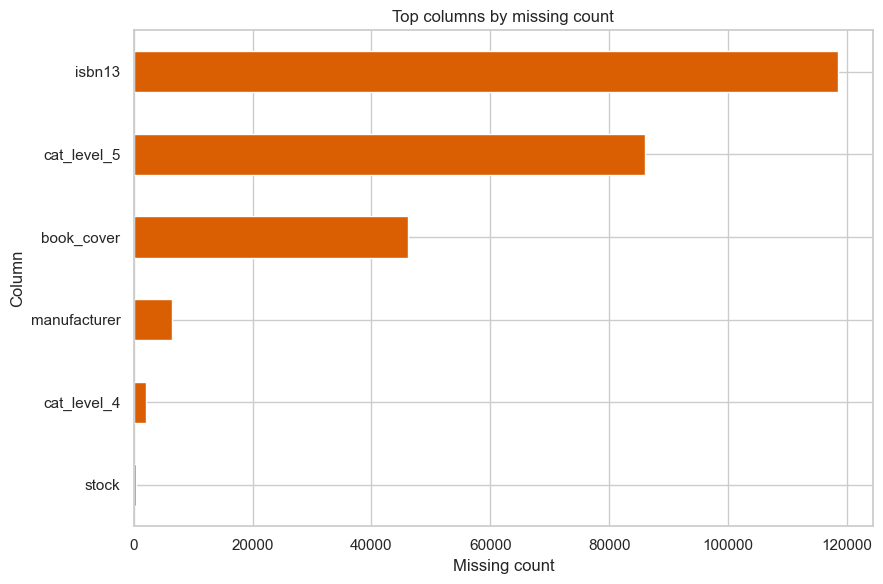

In [6]:
# Basic dataset overview
overview = pd.DataFrame(
    {
        "metric": ["rows", "columns", "memory_mb"],
        "value": [len(df), df.shape[1], round(df.memory_usage(deep=True).sum() / 1024**2, 2)],
    }
)
display(overview)

# Structure and data types
dtype_profile = pd.DataFrame(
    {
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "non_null_count": df.notna().sum().values,
        "missing_count": df.isna().sum().values,
    }
)
dtype_profile["missing_rate_%"] = (dtype_profile["missing_count"] / len(df) * 100).round(3)
display(dtype_profile.sort_values(["missing_count", "column"], ascending=[False, True]))

schema_summary = (
    dtype_profile.groupby("dtype", as_index=False)
    .agg(columns=("column", "count"), total_missing=("missing_count", "sum"))
    .sort_values("columns", ascending=False)
    .reset_index(drop=True)
)
display(schema_summary)

# Duplicate and missing audit
duplicate_id = int(df.duplicated(subset=["id"]).sum()) if "id" in df.columns else np.nan
duplicate_full = int(df.duplicated().sum())
missing_cells = int(df.isna().sum().sum())
total_cells = int(df.shape[0] * df.shape[1])
missing_ratio = (missing_cells / total_cells * 100) if total_cells else np.nan

quality_summary = pd.DataFrame(
    {
        "metric": [
            "duplicate_id_rows",
            "duplicate_full_rows",
            "missing_cells_total",
            "missing_ratio_total_%",
        ],
        "value": [
            duplicate_id,
            duplicate_full,
            missing_cells,
            round(missing_ratio, 4),
        ],
    }
)
display(quality_summary)

missing_by_col = df.isna().sum().sort_values(ascending=False).to_frame("missing_count")
missing_by_col["missing_rate_%"] = (missing_by_col["missing_count"] / len(df) * 100).round(3)
display(missing_by_col.head(25))

non_zero_missing = missing_by_col[missing_by_col["missing_count"] > 0]
if non_zero_missing.empty:
    print("No missing values detected in this processed dataset.")
else:
    ax = non_zero_missing.head(20).sort_values("missing_count").plot(
        kind="barh",
        y="missing_count",
        legend=False,
        figsize=(9, 6),
        color="#d95f02",
    )
    ax.set_title("Top columns by missing count")
    ax.set_xlabel("Missing count")
    ax.set_ylabel("Column")
    plt.tight_layout()
    plt.show()

## 2) Numeric Profile and Outlier Screening

This section analyzes descriptive statistics, distribution shape, and IQR-based outlier rates for numeric features.

In [7]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
print(f"Numeric columns ({len(numeric_cols)}): {numeric_cols}")

if numeric_cols:
    desc = df[numeric_cols].describe(
        percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
    ).T
    desc["skew"] = df[numeric_cols].skew(numeric_only=True)
    display(desc.sort_values("std", ascending=False))

    def iqr_outlier_stats(series: pd.Series) -> tuple[int, float]:
        s = series.dropna()
        if s.empty:
            return 0, 0.0
        q1, q3 = s.quantile([0.25, 0.75])
        iqr = q3 - q1
        if iqr == 0:
            return 0, 0.0
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        outliers = int(((s < lower) | (s > upper)).sum())
        return outliers, outliers / len(s) * 100

    outlier_table = []
    for col in numeric_cols:
        outlier_count, outlier_rate = iqr_outlier_stats(df[col])
        outlier_table.append(
            {
                "column": col,
                "outlier_count": outlier_count,
                "outlier_rate_%": round(outlier_rate, 3),
            }
        )

    outlier_df = pd.DataFrame(outlier_table).sort_values(
        "outlier_rate_%", ascending=False
    )
    display(outlier_df)
else:
    print("No numeric columns found.")

Numeric columns (9): ['id', 'price', 'list_price', 'discount_rate', 'rating_average', 'review_count', 'all_time_quantity_sold', 'number_of_page', 'stock']


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skew
id,"132,955.00","214,044,782.87","89,041,531.82","313,607.00","433,994.66","4,430,752.60","181,993,129.00","270,660,262.00","276,809,067.00","279,032,385.60","279,232,422.92","279,315,919.00",-1.30
number_of_page,"132,955.00","14,409.91","2,313,613.86",0.00,20.00,60.00,216.00,264.00,264.00,532.30,980.00,"436,288,288.00",167.49
list_price,"132,955.00","193,220.84","223,513.64","4,000.00","15,000.00","34,000.00","89,000.00","148,000.00","229,000.00","490,000.00","990,000.00","10,030,000.00",11.18
price,"132,955.00","180,360.89","212,599.77",0.00,"14,400.00","30,000.00","80,000.00","134,800.00","213,000.00","456,000.00","920,000.00","9,990,000.00",10.96
all_time_quantity_sold,"132,955.00",54.11,678.68,0.00,0.00,0.00,0.00,1.00,6.00,130.00,812.00,"75,282.00",47.87
review_count,"132,955.00",6.11,79.50,0.00,0.00,0.00,0.00,0.00,0.00,12.00,95.46,"7,257.00",41.29
discount_rate,"132,955.00",6.73,10.55,0.00,0.00,0.00,0.00,0.00,10.00,30.00,40.00,100.00,1.66
rating_average,"132,955.00",1.14,2.06,0.00,0.00,0.00,0.00,0.00,0.00,5.00,5.00,5.00,1.26
stock,"132,579.00","1,000.00",0.00,"1,000.00","1,000.00","1,000.00","1,000.00","1,000.00","1,000.00","1,000.00","1,000.00","1,000.00",0.00


,column,outlier_count,outlier_rate_%
7,number_of_page,36742,27.64
6,all_time_quantity_sold,23118,17.39
0,id,12382,9.31
3,discount_rate,11024,8.29
2,list_price,8599,6.47
1,price,8315,6.25
4,rating_average,0,0.00
5,review_count,0,0.00
8,stock,0,0.00


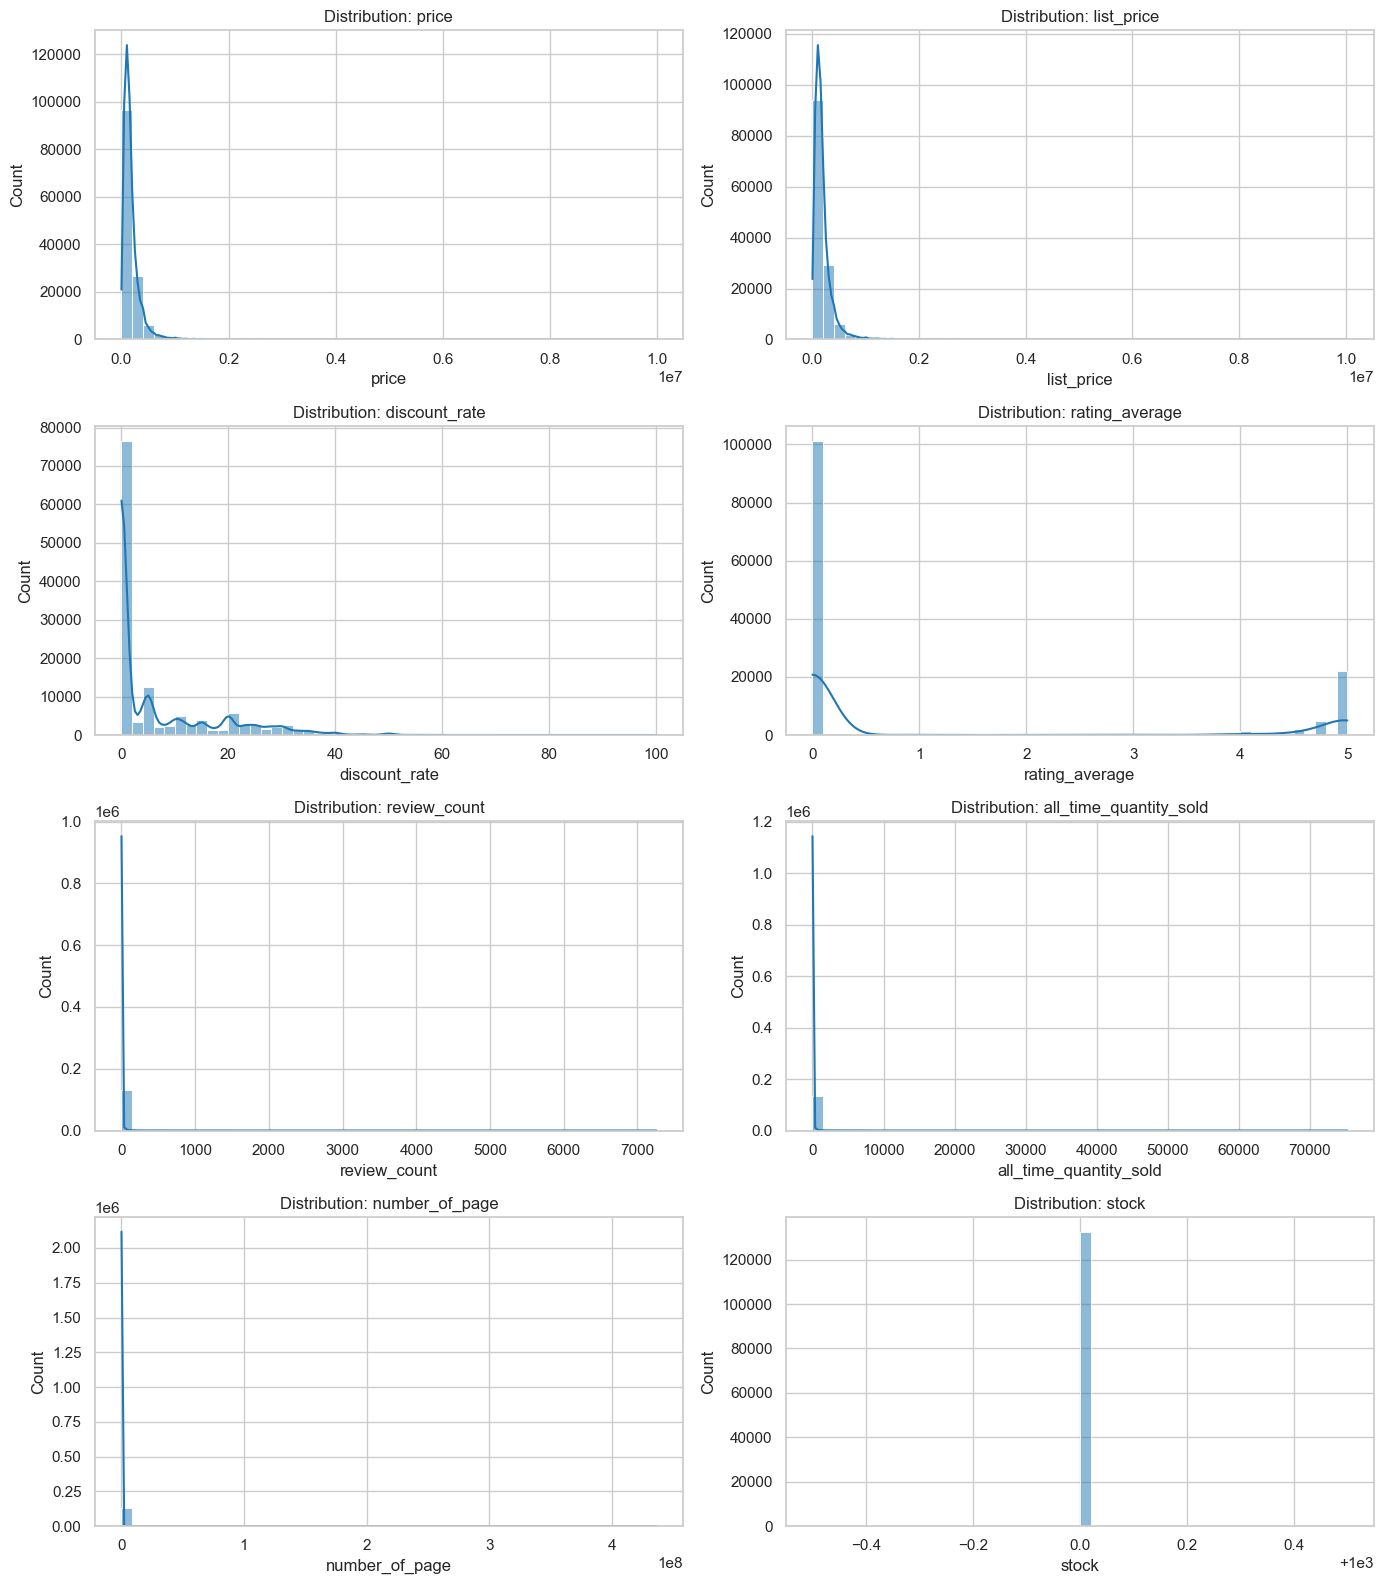

In [8]:
plot_numeric = [
    c
    for c in [
        "price",
        "list_price",
        "discount_rate",
        "rating_average",
        "review_count",
        "all_time_quantity_sold",
        "number_of_page",
        "stock",
    ]
    if c in df.columns
 ]

if plot_numeric:
    n_cols = 2
    n_rows = int(np.ceil(len(plot_numeric) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(plot_numeric):
        s = df[col].dropna()
        ax = axes[i]
        if s.empty:
            ax.set_title(f"{col}: no data")
            ax.axis("off")
            continue
        sns.histplot(s, bins=50, kde=True, ax=ax, color="#1f77b4")
        ax.set_title(f"Distribution: {col}")

    for j in range(len(plot_numeric), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

## 3) Categorical Structure

This section explores category, seller, publisher, and author distributions to describe market structure.

In [9]:
cat_cols = df.select_dtypes(include=["object", "string", "category"]).columns.tolist()
cat_profile = pd.DataFrame(
    {
        "column": cat_cols,
        "unique_values": [df[c].nunique(dropna=True) for c in cat_cols],
        "missing_rate_%": [round(df[c].isna().mean() * 100, 3) for c in cat_cols],
    }
).sort_values(["unique_values", "missing_rate_%"], ascending=[False, False])

display(cat_profile.head(20))

def top_counts(dataframe: pd.DataFrame, col: str, top_n: int = 15) -> pd.DataFrame:
    vc = dataframe[col].fillna("<NA>").value_counts().head(top_n)
    out = vc.rename_axis(col).reset_index(name="count")
    out["share_%"] = (out["count"] / len(dataframe) * 100).round(3)
    return out

for col in ["cat_level_1", "cat_level_2", "publisher_vn", "current_seller_name", "authors"]:
    if col in df.columns:
        print(f"Top values for: {col}")
        display(top_counts(df, col, top_n=15))

,column,unique_values,missing_rate_%
0,name,123273,0.00
1,authors,21639,0.00
4,isbn13,13645,89.09
2,publisher_vn,1310,0.00
3,manufacturer,812,4.79
6,current_seller_name,413,0.00
11,cat_level_4,217,1.54
12,cat_level_5,191,64.63
5,book_cover,46,34.66
10,cat_level_3,33,0.00


Top values for: cat_level_1


,cat_level_1,count,share_%
0,nha-sach-tiki,132955,100.00


Top values for: cat_level_2


,cat_level_2,count,share_%
0,sach-truyen-tieng-viet,117567,88.43
1,sach-tieng-anh,15388,11.57


...

,publisher_vn,count,share_%
0,Nhã Nam,8293,6.24
1,NXB Trẻ,7264,5.46
2,Nhà Sách Hồng Ân,6624,4.98
3,Alphabooks,5377,4.04
4,1980 Books,3989,3.00
5,Thái Hà,3637,2.74
6,Nhà Xuất Bản Kim Đồng,3598,2.71
7,First News - Trí Việt,3214,2.42
8,Alpha Books,3173,2.39
9,AZ Việt Nam,2911,2.19


Top values for: current_seller_name


,current_seller_name,count,share_%
0,Nhà sách Fahasa,25822,19.42
1,Bamboo Books,15941,11.99
2,Tiki Trading,14068,10.58
3,Nhà Sách Vĩnh Thụy,8494,6.39
4,HỆ THỐNG NHÀ SÁCH ABC,5542,4.17
5,info book,5342,4.02
6,Bảo Châu Books,4075,3.06
7,Alpha Books Official,3053,2.30
8,Nhà Sách Phương Nam,2600,1.96
9,NHBook,2593,1.95


Top values for: authors


,authors,count,share_%
0,nhieu tac gia,56372,42.40
1,Nhiều tác giả,1835,1.38
2,.,1344,1.01
3,...,1038,0.78
4,Nguyễn Nhật Ánh,652,0.49
5,Many Authors,467,0.35
6,Thích Nhất Hạnh,297,0.22
7,DK,291,0.22
8,Osho,254,0.19
9,Agatha Christie,221,0.17


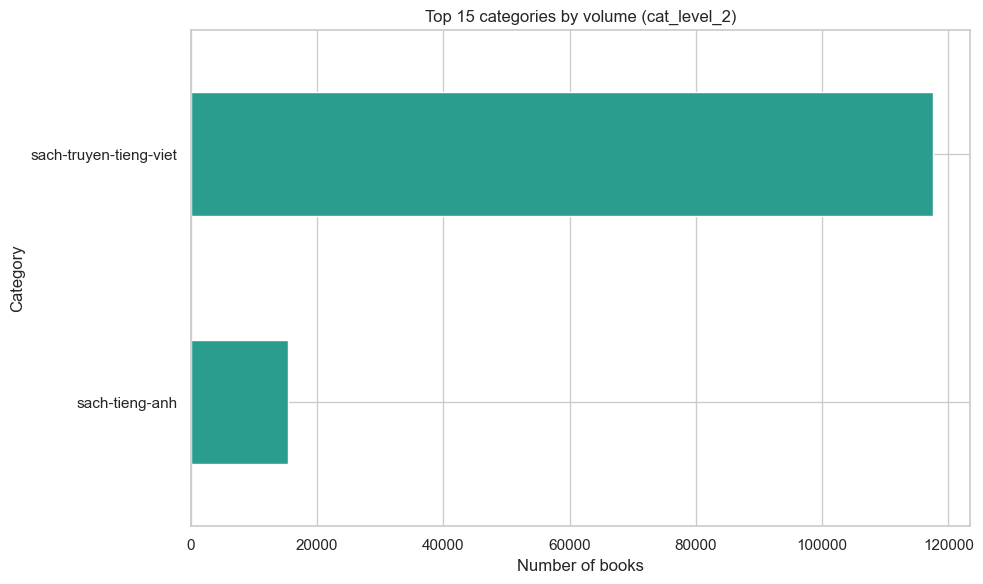

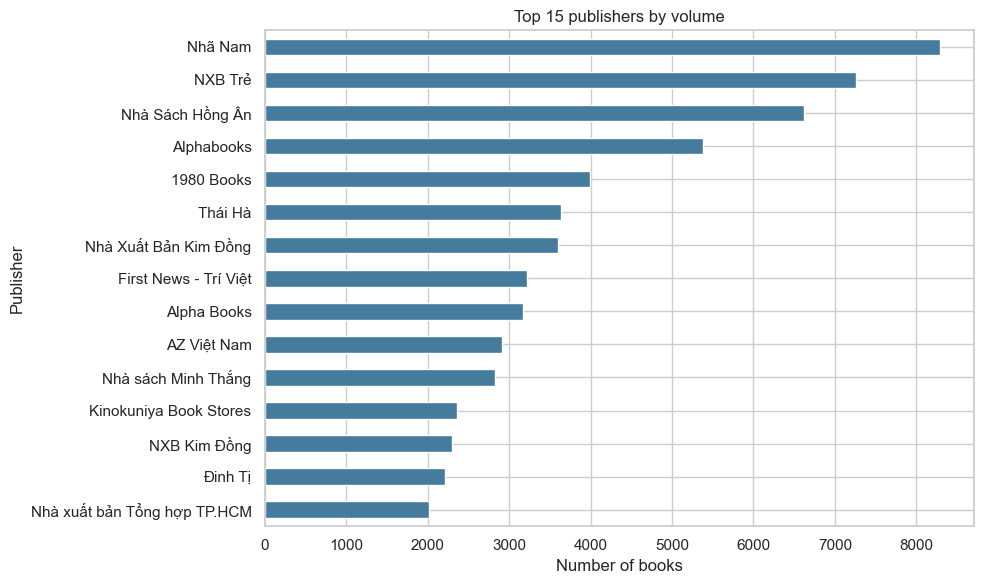

In [10]:
if "cat_level_2" in df.columns:
    top_cat2 = df["cat_level_2"].fillna("<NA>").value_counts().head(15).sort_values()
    plt.figure(figsize=(10, 6))
    top_cat2.plot(kind="barh", color="#2a9d8f")
    plt.title("Top 15 categories by volume (cat_level_2)")
    plt.xlabel("Number of books")
    plt.ylabel("Category")
    plt.tight_layout()
    plt.show()

if "publisher_vn" in df.columns:
    top_pub = df["publisher_vn"].fillna("<NA>").value_counts().head(15).sort_values()
    plt.figure(figsize=(10, 6))
    top_pub.plot(kind="barh", color="#457b9d")
    plt.title("Top 15 publishers by volume")
    plt.xlabel("Number of books")
    plt.ylabel("Publisher")
    plt.tight_layout()
    plt.show()

## 4) Relationship Analysis

This section studies correlations and pairwise relationships among price, discount, rating, review volume, and sales.

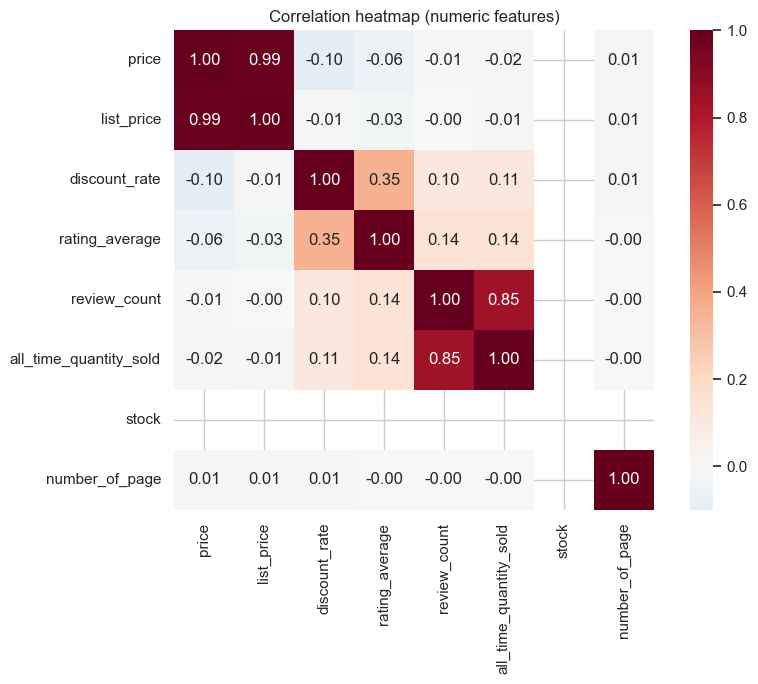

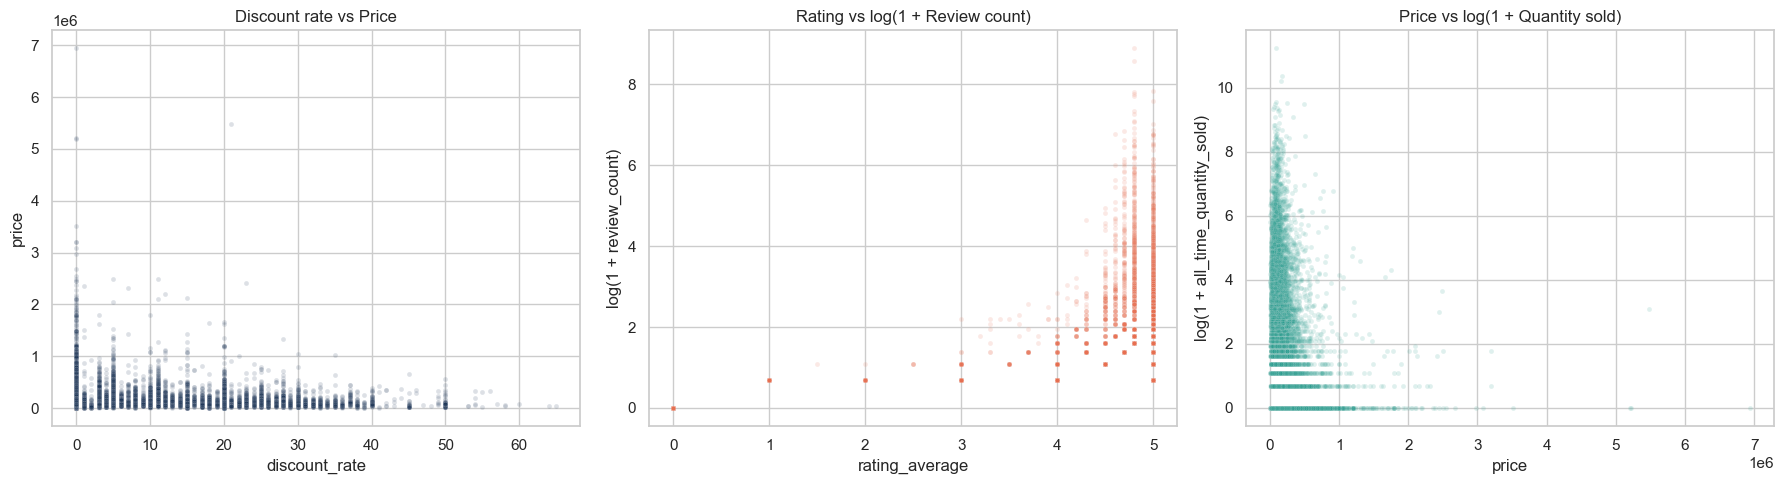

In [11]:
corr_candidates = [
    "price",
    "list_price",
    "discount_rate",
    "rating_average",
    "review_count",
    "all_time_quantity_sold",
    "stock",
    "number_of_page",
]
corr_cols = [c for c in corr_candidates if c in df.columns]

if len(corr_cols) >= 2:
    corr = df[corr_cols].corr(numeric_only=True)
    plt.figure(figsize=(9, 7))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True)
    plt.title("Correlation heatmap (numeric features)")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numeric columns for correlation analysis.")

sample = df.sample(n=min(20000, len(df)), random_state=42).copy()
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

if {"discount_rate", "price"}.issubset(sample.columns):
    sns.scatterplot(
        data=sample, x="discount_rate", y="price", alpha=0.15, s=12, ax=axes[0], color="#1d3557"
    )
    axes[0].set_title("Discount rate vs Price")
else:
    axes[0].text(0.5, 0.5, "Columns not available", ha="center", va="center")
    axes[0].set_axis_off()

if {"rating_average", "review_count"}.issubset(sample.columns):
    sample["review_count_log1p"] = np.log1p(sample["review_count"])
    sns.scatterplot(
        data=sample,
        x="rating_average",
        y="review_count_log1p",
        alpha=0.15,
        s=12,
        ax=axes[1],
        color="#e76f51",
    )
    axes[1].set_title("Rating vs log(1 + Review count)")
    axes[1].set_ylabel("log(1 + review_count)")
else:
    axes[1].text(0.5, 0.5, "Columns not available", ha="center", va="center")
    axes[1].set_axis_off()

if {"price", "all_time_quantity_sold"}.issubset(sample.columns):
    sample["sold_log1p"] = np.log1p(sample["all_time_quantity_sold"])
    sns.scatterplot(
        data=sample,
        x="price",
        y="sold_log1p",
        alpha=0.15,
        s=12,
        ax=axes[2],
        color="#2a9d8f",
    )
    axes[2].set_title("Price vs log(1 + Quantity sold)")
    axes[2].set_ylabel("log(1 + all_time_quantity_sold)")
else:
    axes[2].text(0.5, 0.5, "Columns not available", ha="center", va="center")
    axes[2].set_axis_off()

plt.tight_layout()
plt.show()

## 5) Category, Seller, Time, and Operational Insights

This section summarizes insights by category, seller, publication year, and operational flags (freeship, return policy, authenticity).

Top category-level insights (cat_level_2):


,book_count,median_price,mean_discount_rate,mean_rating,median_review_count,median_quantity_sold
cat_level_2,,,,,,
sach-truyen-tieng-viet,117567,"123,200.00",7.10,1.20,0.00,1.00
sach-tieng-anh,15388,"259,300.00",3.90,0.72,0.00,0.00


Top seller-level insights:


,book_count,median_price,mean_discount_rate,mean_rating,median_review_count,median_quantity_sold
current_seller_name,,,,,,
Nhà sách Fahasa,25822,"136,700.00",7.69,1.39,0.00,1.00
Bamboo Books,15941,"120,000.00",0.09,0.15,0.00,0.00
Tiki Trading,14068,"92,000.00",23.93,3.59,3.00,51.00
Nhà Sách Vĩnh Thụy,8494,"145,000.00",0.00,0.12,0.00,0.00
HỆ THỐNG NHÀ SÁCH ABC,5542,"153,000.00",0.00,0.05,0.00,0.00
info book,5342,"150,000.00",0.00,0.07,0.00,0.00
Bảo Châu Books,4075,"118,000.00",10.85,0.72,0.00,1.00
Alpha Books Official,3053,"175,000.00",16.36,0.93,0.00,1.00
Nhà Sách Phương Nam,2600,"158,000.00",0.44,0.57,0.00,0.00


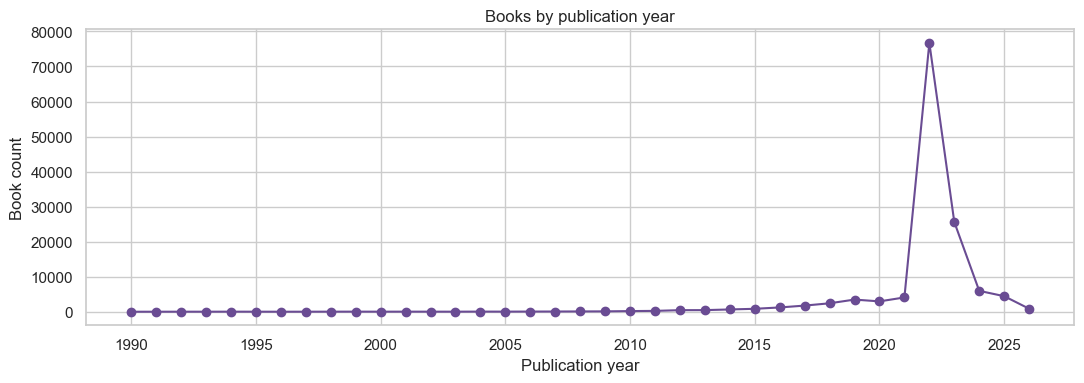

Operational comparison by has_freeship:


,book_count,median_price,mean_rating,median_review_count
has_freeship,,,,
False,13705,"95,200.00",3.56,3.00
True,119250,"139,500.00",0.87,0.00


Operational comparison by has_return_policy:


,book_count,median_price,mean_rating,median_review_count
has_return_policy,,,,
False,379,"223,290.00",0.77,0.00
True,132576,"134,300.00",1.14,0.00


Operational comparison by is_authentic:


,book_count,median_price,mean_rating,median_review_count
is_authentic,,,,
False,2682,"149,000.00",1.37,0.00
True,130273,"134,250.00",1.14,0.00


In [12]:
def summarize_by_group(dataframe: pd.DataFrame, group_col: str, top_n: int = 20) -> pd.DataFrame:
    g = dataframe.groupby(group_col, dropna=False)
    out = pd.DataFrame(index=g.size().index)
    out["book_count"] = g.size()

    if "price" in dataframe.columns:
        out["median_price"] = g["price"].median()
    if "discount_rate" in dataframe.columns:
        out["mean_discount_rate"] = g["discount_rate"].mean()
    if "rating_average" in dataframe.columns:
        out["mean_rating"] = g["rating_average"].mean()
    if "review_count" in dataframe.columns:
        out["median_review_count"] = g["review_count"].median()
    if "all_time_quantity_sold" in dataframe.columns:
        out["median_quantity_sold"] = g["all_time_quantity_sold"].median()

    return out.sort_values("book_count", ascending=False).head(top_n).round(3)

if "cat_level_2" in df.columns:
    cat2_stats = summarize_by_group(df, "cat_level_2", top_n=20)
    print("Top category-level insights (cat_level_2):")
    display(cat2_stats)

if "current_seller_name" in df.columns:
    seller_stats = summarize_by_group(df, "current_seller_name", top_n=15)
    print("Top seller-level insights:")
    display(seller_stats)

if "publication_date" in df.columns:
    valid_date = df.dropna(subset=["publication_date"]).copy()
    if not valid_date.empty:
        valid_date["pub_year"] = valid_date["publication_date"].dt.year
        valid_date = valid_date[
            (valid_date["pub_year"] >= 1990)
            & (valid_date["pub_year"] <= pd.Timestamp.today().year)
        ]

        yearly_counts = valid_date["pub_year"].value_counts().sort_index()
        plt.figure(figsize=(11, 4))
        yearly_counts.plot(kind="line", marker="o", color="#6a4c93")
        plt.title("Books by publication year")
        plt.xlabel("Publication year")
        plt.ylabel("Book count")
        plt.tight_layout()
        plt.show()

for col in ["has_freeship", "has_return_policy", "is_authentic"]:
    if col in df.columns:
        compare = df.groupby(col).agg(
            book_count=("id", "count") if "id" in df.columns else (df.columns[0], "count"),
            median_price=("price", "median") if "price" in df.columns else (df.columns[0], "count"),
            mean_rating=("rating_average", "mean") if "rating_average" in df.columns else (df.columns[0], "count"),
            median_review_count=("review_count", "median") if "review_count" in df.columns else (df.columns[0], "count"),
        )
        print(f"Operational comparison by {col}:")
        display(compare.round(3))

## 6) Key EDA Conclusions

Quick summary of the most important metrics and findings for reporting.

In [13]:
insights = {}

if "cat_level_2" in df.columns:
    top_cat2_name = df["cat_level_2"].fillna("<NA>").value_counts().index[0]
    top_cat2_count = int(df["cat_level_2"].fillna("<NA>").value_counts().iloc[0])
    insights["top_cat_level_2"] = f"{top_cat2_name} ({top_cat2_count:,} books)"

if "publisher_vn" in df.columns:
    top_publisher = df["publisher_vn"].fillna("<NA>").value_counts().index[0]
    top_publisher_count = int(df["publisher_vn"].fillna("<NA>").value_counts().iloc[0])
    insights["top_publisher"] = f"{top_publisher} ({top_publisher_count:,} books)"

if "current_seller_name" in df.columns:
    top_seller = df["current_seller_name"].fillna("<NA>").value_counts().index[0]
    top_seller_count = int(df["current_seller_name"].fillna("<NA>").value_counts().iloc[0])
    insights["top_seller"] = f"{top_seller} ({top_seller_count:,} books)"

if "discount_rate" in df.columns:
    insights["median_discount_rate"] = float(df["discount_rate"].median())

if "price" in df.columns:
    insights["median_price"] = float(df["price"].median())

if "rating_average" in df.columns:
    insights["median_rating"] = float(df["rating_average"].median())

if "review_count" in df.columns:
    insights["median_review_count"] = float(df["review_count"].median())

if "all_time_quantity_sold" in df.columns:
    insights["median_quantity_sold"] = float(df["all_time_quantity_sold"].median())

print("EDA summary insights:")
for k, v in insights.items():
    print(f"- {k}: {v}")

insights

EDA summary insights:
- top_cat_level_2: sach-truyen-tieng-viet (117,567 books)
- top_publisher: Nhã Nam (8,293 books)
- top_seller: Nhà sách Fahasa (25,822 books)
- median_discount_rate: 0.0
- median_price: 134800.0
- median_rating: 0.0
- median_review_count: 0.0
- median_quantity_sold: 1.0


{'top_cat_level_2': 'sach-truyen-tieng-viet (117,567 books)',
 'top_publisher': 'Nhã Nam (8,293 books)',
 'top_seller': 'Nhà sách Fahasa (25,822 books)',
 'median_discount_rate': 0.0,
 'median_price': 134800.0,
 'median_rating': 0.0,
 'median_review_count': 0.0,
 'median_quantity_sold': 1.0}